<a href="https://colab.research.google.com/github/AlejandroVasquez3/DDDS-My-Projects/blob/main/Project-6/Project_Images_DL_Final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Images – To Do List


#### Resources
- [1a-File.Handling.with.Pickle.end.ipynb](https://drive.google.com/file/d/1tfoftNRhpWyYx_gd5j8wU1PSz2WBiu-I/view?usp=drive_link)
- [1b-Deep.Learning.pptx](https://docs.google.com/presentation/d/1rQItVh4smSB7DXayC3wr6WQrc8op1hmA/edit?usp=drive_link&ouid=115669507201437811032&rtpof=true&sd=true)
- [1c-Deep.Learning.Example-ANN.end.ipynb](https://drive.google.com/file/d/17BKMc3nx6XvZCkaIdBQrjJu_h9y7FDa5/view?usp=drive_link)
- [1d-Convolutional_Neural_Networks.pptx](https://docs.google.com/presentation/d/11h5thI19kVXbzHkvEsYZw503_h3xEUNq/edit?usp=drive_link&ouid=115669507201437811032&rtpof=true&sd=true)
- [1e-Deep.Learning.Example-CNN.end.ipynb](https://drive.google.com/file/d/1KaGYTsahhDsmSiqcsfbbWFKf5Wsimd9w/view?usp=drive_link)


Prior to starting this problem, be sure to enable the GPU runtime processing in your Jupyter notebook.



## Problem Definition



* This data science problem is a supervised learning problem. We will use deep learning to classify whether an image is a dog or a cat.

In [ ]:
import numpy as np
import pandas as pd
import pickle
import tensorflow.keras as keras
import tensorflow as tf
import matplotlib.pyplot as plt

from sklearn import datasets
from keras.models import Sequential
from keras.layers import Dense, Input, Flatten, Conv2D, MaxPooling2D
from keras.utils import plot_model
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


## Data Collection



* Load pickled data from X.pickle and y.pickle from the AWS S3 bucket.



In [ ]:
url_x = "https://ddc-datascience.s3.amazonaws.com/Projects/Project.6-Images/Data/X.pickle"
url_y = "https://ddc-datascience.s3.amazonaws.com/Projects/Project.6-Images/Data/y.pickle"

In [ ]:
!curl -O {url_x}

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100  237M  100  237M    0     0  16.9M      0  0:00:14  0:00:14 --:--:-- 19.3M


In [ ]:
!curl -O {url_y}

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100 49948  100 49948    0     0  62026      0 --:--:-- --:--:-- --:--:-- 61970


In [ ]:
data_x = pd.read_pickle(url_x)

In [ ]:
data_x.shape

(24946, 100, 100, 1)

In [ ]:
data_y = pd.read_pickle(url_y)

In [ ]:
type(data_y)

list

In [ ]:
ls -la --si


total 250M
drwxr-xr-x 1 root root 4.1k Jul 16 19:16 ./
drwxr-xr-x 1 root root 4.1k Jul 16 18:59 ../
drwxr-xr-x 4 root root 4.1k Jul 15 13:41 .config/
drwxr-xr-x 1 root root 4.1k Jul 15 13:41 sample_data/
-rw-r--r-- 1 root root 250M Jul 16 19:16 X.pickle
-rw-r--r-- 1 root root  50k Jul 16 19:16 y.pickle


In [ ]:
!ls -la --si ./X.pickle


-rw-r--r-- 1 root root 250M Jul 16 19:16 ./X.pickle


In [ ]:
!ls -la --si ./y.pickle


-rw-r--r-- 1 root root 50k Jul 16 19:16 ./y.pickle


In [ ]:
!ls -la --si ./*.pickle

-rw-r--r-- 1 root root 250M Jul 16 19:16 ./X.pickle
-rw-r--r-- 1 root root  50k Jul 16 19:16 ./y.pickle


In [ ]:
with open('X.pickle', 'rb') as file:
    data_x = pickle.load(file)


In [ ]:
type(data_x)


numpy.ndarray

In [ ]:
data_x.shape

(24946, 100, 100, 1)

In [ ]:
with open('y.pickle', 'rb') as file:
    data_y = pickle.load(file)


In [ ]:
y_np = np.array(data_y)
y_np

array([0, 1, 1, ..., 1, 0, 1])

## Data Cleaning



* Scale the values in X so that they fall between 0 and 1 by dividing by 255.



In [ ]:
data_x_scaled = data_x/225.0

## Exploratory Data Analysis



* Look at the shape of X and y. Ensure that X is 4 dimensional.

* Plot a few ( >5 ) of the images in X using `plt.imshow()`.

* Look at the response values in y for those images.

* Hint: you may want to start with a random subset to get familiar with the process of building a NN.  Then go through the process again with the full set.



#### Shape of X and y

In [ ]:
# Shape of X
data_x.shape

(24946, 100, 100, 1)

In [ ]:
y_np.shape

(24946,)

#### Plotting Images

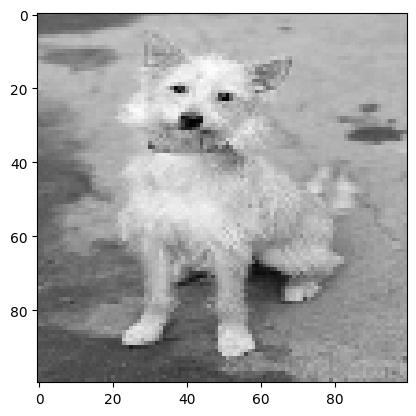


The y value for the image is: 0


In [ ]:
plt.imshow( data_x_scaled[0], cmap = plt.cm.gray )
plt.show()
print(f"\nThe y value for the image is: {data_y[0]}")

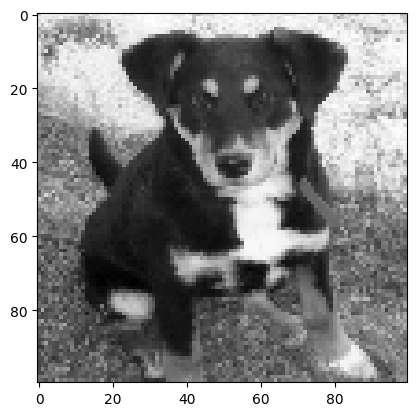


The y value for the image is: 0


In [ ]:
plt.imshow( data_x_scaled[2125], cmap = plt.cm.gray )
plt.show()
print(f"\nThe y value for the image is: {data_y[2125]}")

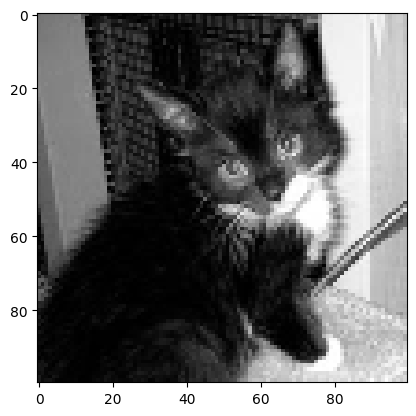


The y value for the image is: 1


In [ ]:
plt.imshow( data_x_scaled[10], cmap = plt.cm.gray )
plt.show()
print(f"\nThe y value for the image is: {data_y[10]}")

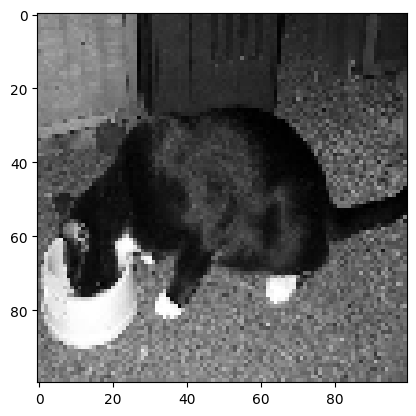


The y value for the image is: 1


In [ ]:
plt.imshow( data_x_scaled[24945], cmap = plt.cm.gray )
plt.show()
print(f"\nThe y value for the image is: {data_y[24945]}")

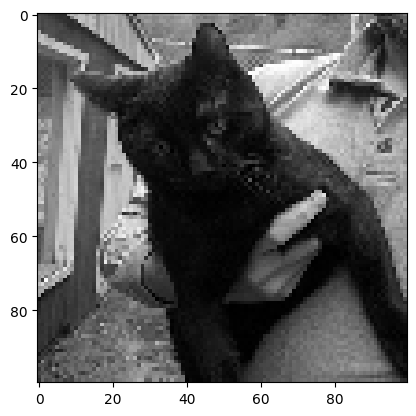


The y value for the image is: 1


In [ ]:
plt.imshow( data_x_scaled[4200], cmap = plt.cm.gray )
plt.show()
print(f"\nThe y value for the image is: {data_y[4200]}")

## Data Processing



* Split X and y into training and testing sets.

*  Build a convolutional neural network with the following:
  * Sequential layers
  * At least two 2D convolutional layers using the 'relu' activation function and a (3,3) kernel size.
  * A MaxPooling2D layer after each 2D convolutional layer that has a pool size of (2,2).
  * A dense output layer using the 'sigmoid' activation function.
  Note: you can play around with the number of layers and nodes to try to get better performance.

* Compile your model. Use the 'adam' optimizer. Determine which loss function and metric is most appropriate for this problem.

* Fit your model using the training set.

* Evaluate your model using the testing set.

* Plot the distribution of probabilities for the testing set.

* Define a function that will read in a new image and convert it to a 4 dimensional array of pixels (ask the instructor for help with this). Hint: [numpy.reshape]( https://numpy.org/doc/stable/reference/generated/numpy.reshape.html )

* Use the function defined above to read in the dog.jpg image that is saved in the AWS S3 bucket.

* Use the neural network you created to predict whether the image is a dog or a cat.



In [ ]:
# Split the data up in train and test sets
X_train, X_test, y_train, y_test = train_test_split(data_x_scaled, y_np, test_size=0.25, random_state=42)

In [ ]:
(
  X_train.shape,
  y_train.shape,
  X_test.shape,
  y_test.shape
)


((18709, 100, 100, 1), (18709,), (6237, 100, 100, 1), (6237,))

In [ ]:
X_train.shape

(18709, 100, 100, 1)

In [ ]:
X_test.shape

(6237, 100, 100, 1)

In [ ]:
# shape of a single image
X_train.shape[1:]

(100, 100, 1)

In [ ]:
model = Sequential()

In [ ]:
# Define input layer
model.add(
  Input(
    shape=X_train.shape[1:],
    name="model_input",
  ),
)


In [ ]:
# Define first hidden layer
model.add(
  Conv2D(
    name = "Conv1",
    filters = 64,
    kernel_size = (3,3),
    activation = 'relu',
  )
)

model.add(
    MaxPooling2D(pool_size=(2,2))
)


In [ ]:
# Define second hidden layer
model.add(
  Conv2D(
    name = "Conv2",
    filters = 64,
    kernel_size = (3,3),
    activation = 'relu',
  )
)

model.add(
  MaxPooling2D(pool_size=(2,2))
)


In [ ]:
# Define Third hidden layer
model.add(
  Conv2D(
    name = "Conv3",
    filters = 64,
    kernel_size = (3,3),
    activation = 'relu',
  )
)

model.add(
    MaxPooling2D(pool_size=(2,2))
)


In [ ]:
# Flatten data to be used in output layer
model.add(
    Flatten()
)

# Define output layer
model.add(
  Dense(
    name = "output",
    units = 1,
    activation = 'sigmoid',
  )
)


In [ ]:
# Compile model
model.compile(
  optimizer = 'adam',
  loss = 'binary_crossentropy',
  metrics = ['accuracy'],
)


In [ ]:
# Fit model
model.fit(X_train, y_train, epochs=8)

Epoch 1/8
585/585 ━━━━━━━━━━━━━━━━━━━━ 11s 14ms/step - accuracy: 0.5892 - loss: 0.6609
Epoch 2/8
585/585 ━━━━━━━━━━━━━━━━━━━━ 7s 12ms/step - accuracy: 0.7431 - loss: 0.5240
Epoch 3/8
585/585 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - accuracy: 0.7875 - loss: 0.4498
Epoch 4/8
585/585 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - accuracy: 0.8155 - loss: 0.4085
Epoch 5/8
585/585 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - accuracy: 0.8406 - loss: 0.3677
Epoch 6/8
585/585 ━━━━━━━━━━━━━━━━━━━━ 7s 12ms/step - accuracy: 0.8484 - loss: 0.3387
Epoch 7/8
585/585 ━━━━━━━━━━━━━━━━━━━━ 7s 12ms/step - accuracy: 0.8772 - loss: 0.2900
Epoch 8/8
585/585 ━━━━━━━━━━━━━━━━━━━━ 7s 12ms/step - accuracy: 0.8876 - loss: 0.2660


In [ ]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Conv1 (Conv2D)                  │ (None, 98, 98, 64)     │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 49, 49, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Conv2 (Conv2D)                  │ (None, 47, 47, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 23, 23, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Conv3 (Conv2D)                  │ (None, 21, 21, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 10, 10, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 6400)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │         6,401 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 242,693 (948.02 KB)

 Trainable params: 80,897 (316.00 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 161,796 (632.02 KB)

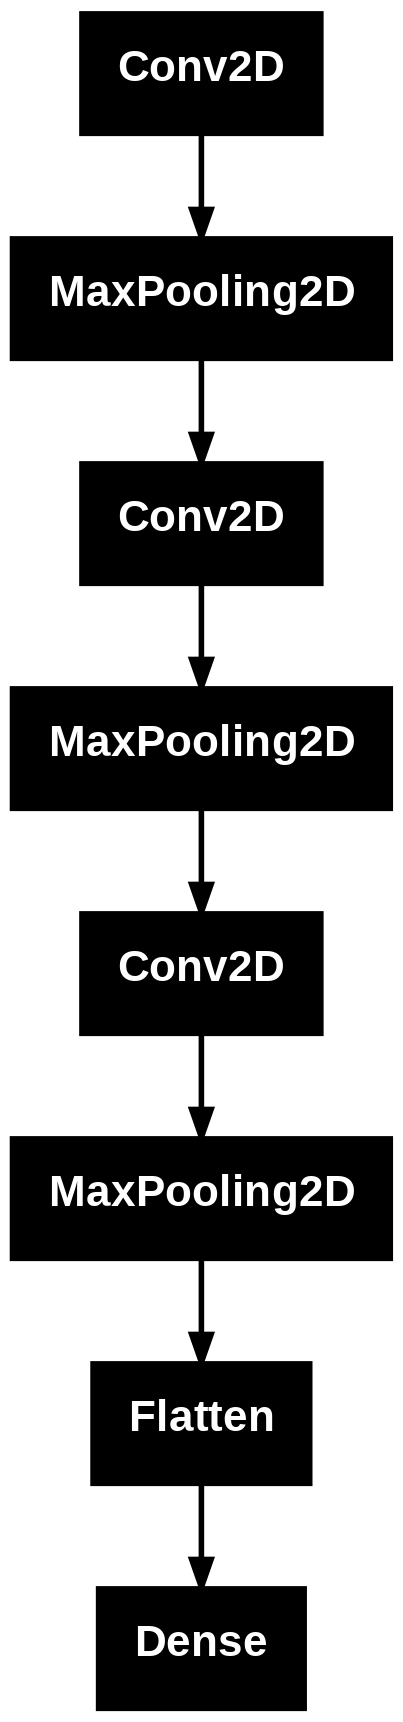

In [ ]:
plot_model(model)

In [ ]:
# Change test set to 4-D
X_test2 = X_test.reshape( X_test.shape + (1,) )

# Evaluate model
val_loss, val_acc = model.evaluate(X_test2, y_test)
print(val_loss)
print(val_acc)

195/195 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8416 - loss: 0.3475
0.34774231910705566
0.8455988168716431


In [ ]:
# make predictions based on testing set
predictions = model.predict(X_test2)


195/195 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step


In [ ]:
predictions.shape

(6237, 1)

0: 26.70
Actual Value: 0


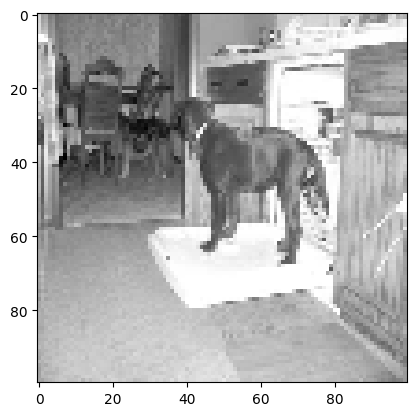

In [ ]:
# pick any image from 0 to 6236
# i = 6236
# i = 160
# i = 2982
i = 100



for k, x in enumerate(predictions[i]*100):
  print(f"{k}: {x:.2f}")

print(f"Actual Value: {y_test[i]}")
plt.imshow(X_test[i], cmap=plt.cm.gray)
plt.show()

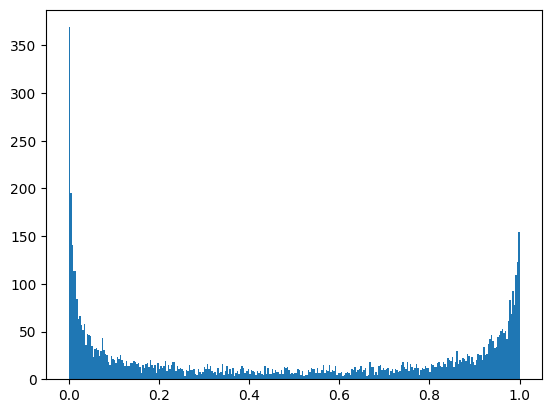

In [ ]:
plt.hist(predictions, bins= 300);

(array([3092.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,
        3145.]),
 array([0. , 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1. ]),
 <BarContainer object of 10 artists>)

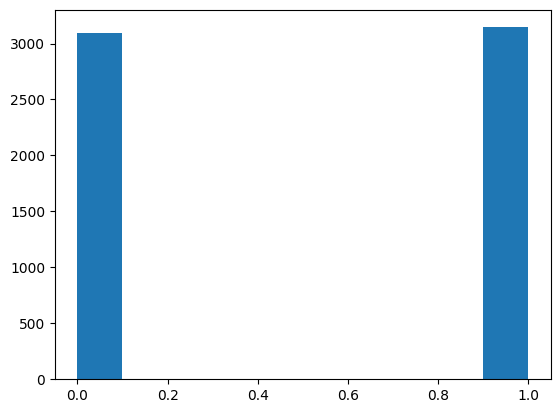

In [ ]:
plt.hist(y_test)

#### Image convert function
- Define a function that will read in a new image and convert it to a 4 dimensional array of pixels (ask the instructor for help with this). Hint: numpy.reshape

In [ ]:
# Import needed libraries for image conversion and display
from PIL import Image
import requests
import urllib.request
import io

In [ ]:
pip install Pillow requests

In [ ]:
# Image conversion function for Deep Learing
def image_DL_conversion(image_path, target_size= (100,100)):
  """
  Reads an image, coverts ot to grayscale, resize, converts to 4-d np array, and normalizes to 0-1

  Args:
  image_path (str): The file path to the image.
  target_size (tuple): A tuple (width, height) for resizing the image.
  Default is (100, 100) to match your dataset

  Returns image
  """

  # load image path
  img = Image.open(image_path)

  # Convert image to grayscale
  img = img.convert("L")

  # resize image to 100x100 pixels
  img = img.resize(target_size)

  #Image to np.array
  img_array = np.array(img)

  # Adjusting dimensions of image array
  # (target_size[0], target_size[1]) These values could be hard coded but
  # I wanted to have it adjustable for future use.
  # img_array = img_array.reshape(1, 100, 100, 1) for example
  img_array_shaped = img_array.reshape(1,target_size[0], target_size[1], 1)

  # Normalize the image pixel values to 0-1
  # Scale pixel values to from 0-225 to 0-1 (divide by 255)
  img_array_norm = img_array_shaped/255

  return img_array_shaped



#### dog.jpg image conversion
- Use the function defined above to read in the dog.jpg image that is saved in the AWS S3 bucket.

In [ ]:
!curl -O https://ddc-datascience.s3.amazonaws.com/Projects/Project.6-Images/Data/dog.jpg

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100 60603  100 60603    0     0  61462      0 --:--:-- --:--:-- --:--:-- 61463


In [ ]:
# path to image localy
path = "/content/dog.jpg"

In [ ]:
foo = image_DL_conversion("/content/dog.jpg")

In [ ]:
type(foo)

numpy.ndarray

#### Cat or Dog - dog.jpg
- Use the neural network you created to predict whether the image is a dog or a cat.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 475ms/step
The neural network predicts the image is: 1.0000
This image is predicted to be a DOG.


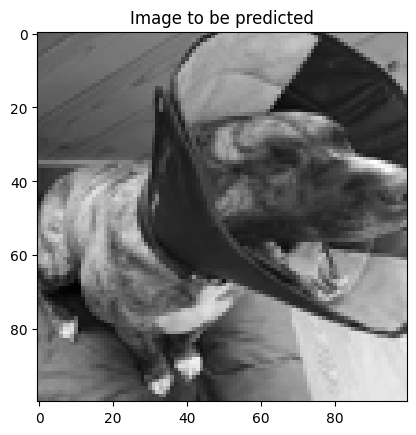

In [ ]:
# Test our Nerual Network to see if the image dog.jpg is a Cat or Dog
# Use the neural network to predict whether the image is a dog or a cat
prediction_dog_jpg = model.predict(foo)

# Print the prediction (it will be a probability)
print(f"The neural network predicts the image is: {prediction_dog_jpg[0][0]:.4f}")

# Interpret the prediction
if prediction_dog_jpg[0][0] > 0.5:
  print("This image is predicted to be a DOG.")
else:
  print("This image is predicted to be a CAT.")

# You can also display the image to visually confirm
plt.imshow(foo[0], cmap=plt.cm.gray)
plt.title("Image to be predicted")
plt.show()

## Communication of Results



* Communicate the results of your analysis.



## **BONUS** (optional)



* Upload an image of your (or your friend's or family's) dog or cat and use your model to predict whether the image is a dog or cat.
* Hint: you'll probably need to convert the image from color to grayscale.  OpenCV, pillow, and other libraries are your friend.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
The neural network predicts the image is: 1.0000
This image is predicted to be a DOG.


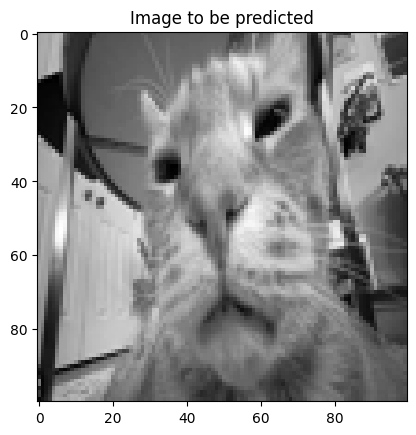

In [ ]:
# covert image we would like to identify
foo = image_DL_conversion("/content/pic_01.png")

# Test our Nerual Network to see if the image dog.jpg is a Cat or Dog
# Use the neural network to predict whether the image is a dog or a cat
prediction_dog_jpg = model.predict(foo)

# Print the prediction (it will be a probability)
print(f"The neural network predicts the image is: {prediction_dog_jpg[0][0]:.4f}")

# Interpret the prediction
if prediction_dog_jpg[0][0] > 0.5:
  print("This image is predicted to be a DOG.")
else:
  print("This image is predicted to be a CAT.")

# You can also display the image to visually confirm
plt.imshow(foo[0], cmap=plt.cm.gray)
plt.title("Image to be predicted")
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
The neural network predicts the image is: 0.0000
This image is predicted to be a CAT.


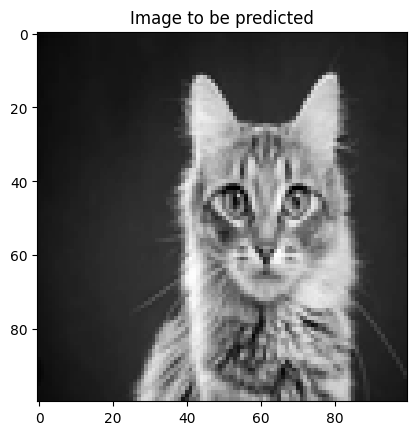

In [ ]:
# covert image we would like to identify
foo = image_DL_conversion("/content/pic_02.png")

# Test our Nerual Network to see if the image dog.jpg is a Cat or Dog
# Use the neural network to predict whether the image is a dog or a cat
prediction_dog_jpg = model.predict(foo)

# Print the prediction (it will be a probability)
print(f"The neural network predicts the image is: {prediction_dog_jpg[0][0]:.4f}")

# Interpret the prediction
if prediction_dog_jpg[0][0] > 0.5:
  print("This image is predicted to be a DOG.")
else:
  print("This image is predicted to be a CAT.")

# You can also display the image to visually confirm
plt.imshow(foo[0], cmap=plt.cm.gray)
plt.title("Image to be predicted")
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
The neural network predicts the image is: 0.0000
This image is predicted to be a CAT.


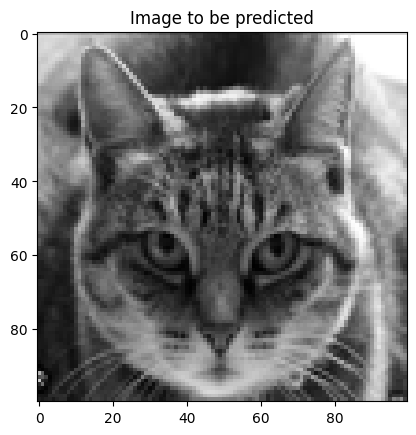

In [ ]:
# covert image we would like to identify
foo = image_DL_conversion("/content/pic_03.png")

# Test our Nerual Network to see if the image dog.jpg is a Cat or Dog
# Use the neural network to predict whether the image is a dog or a cat
prediction_dog_jpg = model.predict(foo)

# Print the prediction (it will be a probability)
print(f"The neural network predicts the image is: {prediction_dog_jpg[0][0]:.4f}")

# Interpret the prediction
if prediction_dog_jpg[0][0] > 0.5:
  print("This image is predicted to be a DOG.")
else:
  print("This image is predicted to be a CAT.")

# You can also display the image to visually confirm
plt.imshow(foo[0], cmap=plt.cm.gray)
plt.title("Image to be predicted")
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
The neural network predicts the image is: 0.0000
This image is predicted to be a CAT.


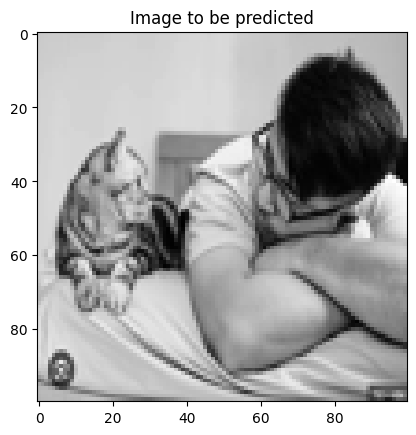

In [ ]:
# covert image we would like to identify
foo = image_DL_conversion("/content/pic_04.png")

# Test our Nerual Network to see if the image dog.jpg is a Cat or Dog
# Use the neural network to predict whether the image is a dog or a cat
prediction_dog_jpg = model.predict(foo)

# Print the prediction (it will be a probability)
print(f"The neural network predicts the image is: {prediction_dog_jpg[0][0]:.4f}")

# Interpret the prediction
if prediction_dog_jpg[0][0] > 0.5:
  print("This image is predicted to be a DOG.")
else:
  print("This image is predicted to be a CAT.")

# You can also display the image to visually confirm
plt.imshow(foo[0], cmap=plt.cm.gray)
plt.title("Image to be predicted")
plt.show()